In [1]:
import os

In [2]:
%pwd

'd:\\a27_YEARS_OLD\\nlp_text_summarization\\research'

In [3]:
os.chdir("../")

In [4]:
%pwd

'd:\\a27_YEARS_OLD\\nlp_text_summarization'

In [1]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class ModelTrainerConfig:
    root_dir: Path
    data_path: Path
    model_ckpt: Path
    num_train_epochs: int
    warmup_steps: int
    per_device_train_batch_size: int
    weight_decay: float
    logging_steps: int
    evaluation_strategy: str
    eval_steps: int
    save_steps: float
    gradient_accumulation_steps: int

In [6]:
from textSummarizer.constants import *
from textSummarizer.utils.common import read_yaml, create_directories

In [7]:
class ConfigurationManager:
    def __init__(
            self,
            config_filepath = CONFIG_FILE_PATH,
            params_filepath = PARAMS_FILE_PATH):
        
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])

    def get_model_trainer_config(self) -> ModelTrainerConfig:
        config = self.config.model_trainer
        params = self.params.TrainingArguments

        create_directories([config.root_dir])

        model_trainer_config = ModelTrainerConfig(
            root_dir=config.root_dir, # artifacts/model_trainer
            data_path=config.data_path, # artifacts/data_transformation/samsum_dataset
            model_ckpt = config.model_ckpt,  # google/pegasus-cnn_dailymail
            num_train_epochs = params.num_train_epochs,
            warmup_steps = params.warmup_steps,
            per_device_train_batch_size = params.per_device_train_batch_size,
            weight_decay = params.weight_decay,
            logging_steps = params.logging_steps,
            evaluation_strategy = params.evaluation_strategy,
            eval_steps = params.evaluation_strategy,
            save_steps = params.save_steps,
            gradient_accumulation_steps = params.gradient_accumulation_steps
        )
        return model_trainer_config







    

In [8]:
from transformers import TrainingArguments, Trainer
from transformers import DataCollatorForSeq2Seq
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from datasets import load_dataset, load_from_disk
import torch

d:\a27_YEARS_OLD\nlp_text_summarization\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2025-02-09 21:58:46,612: INFO: config: PyTorch version 2.4.1 available.]


In [9]:
from accelerate import Accelerator

In [10]:
!pip show accelerate

Name: accelerate
Version: 0.34.2
Summary: Accelerate
Home-page: https://github.com/huggingface/accelerate
Author: The HuggingFace team
Author-email: zach.mueller@huggingface.co
License: Apache
Location: D:\a27_YEARS_OLD\nlp_text_summarization\venv\Lib\site-packages
Requires: huggingface-hub, numpy, packaging, psutil, pyyaml, safetensors, torch
Required-by: 


In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


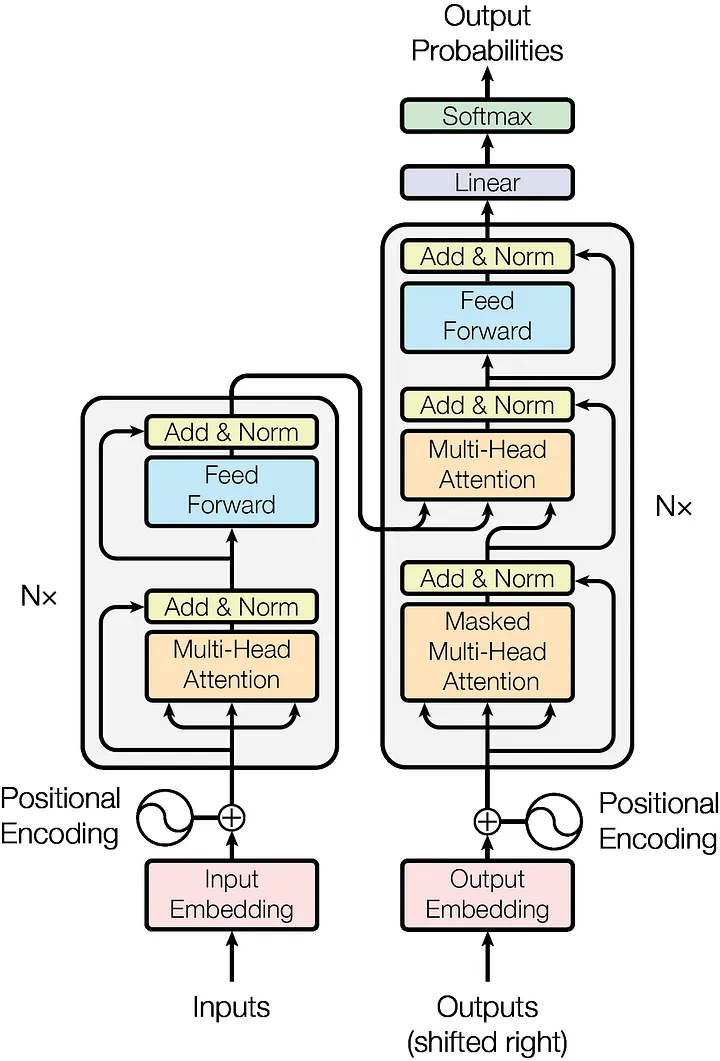

Fine-Tuning

In [ ]:
# The pipeline function creates an instance of a specific task, in this case, 
# 'summarization'. We're also specifying which model checkpoint (model_ckpt) to use. Recall 
# that model_ckpt was set to "google/pegasus-cnn_dailymail" in the previous code snippets. So, 
# this pipeline will be using the PEGASUS model trained on the CNN/DailyMail dataset for summarization.

In [14]:
class ModelTrainer:
    def __init__(self, config: ModelTrainerConfig):
        self.config = config

    def train(self):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        tokenizer = AutoTokenizer.from_pretrained(self.config.model_ckpt) # google/pegasus-cnn_dailymail
        model_pegasus = AutoModelForSeq2SeqLM.from_pretrained(self.config.model_ckpt).to(device)
        seq2seq_data_collator = DataCollatorForSeq2Seq(tokenizer, model=model_pegasus)


        #loading data 
        dataset_samsum_pt = load_from_disk(self.config.data_path)


        if device == "cuda":
            accelerator_arg = "ddp"
        else:
            accelerator_arg = "cpu"

        # Initialize accelerator
        accelerator = Accelerator()
            # accelerator=accelerator_arg,
            # device=device,
        # )

        trainer_args = TrainingArguments(
            output_dir=self.config.root_dir,
            num_train_epochs=1, 
            warmup_steps=5, # defines the number of warm-up steps for the learning rate scheduler. During these steps, the learning rate will increase linearly from 0 to the maximum learning rate.
            per_device_train_batch_size=1, # sets the batch size for training to 1 sample per device.
            per_device_eval_batch_size=1, # sets the batch size for evaluation to 1 sample per device.
            weight_decay=0.01, # applies L2 regularization (weight decay) to the model's weights with a coefficient of 0.01.
            logging_steps=10, # controls how often the training process logs information, such as the loss and learning rate. In this case, logging occurs every 10 steps.
            evaluation_strategy='steps', 
            eval_steps=5,  # sets the interval for evaluation to every 500 steps.
            save_steps=10, # ontrols how often the model's checkpoints are saved. In this case, checkpoints are saved every 1,000,000 steps.
            gradient_accumulation_steps=16, # enables gradient accumulation, which allows the model to accumulate gradients from multiple batches before performing a weight update. 
            # This can help reduce memory usage and improve training efficiency. In this case, gradients are accumulated over 16 batches.
            
        )

        trainer = Trainer(
            model=model_pegasus, 
            args=trainer_args,
            tokenizer=tokenizer, 
            data_collator=seq2seq_data_collator,
            train_dataset=dataset_samsum_pt["train"],  # it takes lot of time for cpu so  I interruped
            eval_dataset=dataset_samsum_pt["validation"]
        )
        
        trainer.train()

        ## Save model
        model_pegasus.save_pretrained(os.path.join(self.config.root_dir,"pegasus-samsum-model"))
        ## Save tokenizer
        tokenizer.save_pretrained(os.path.join(self.config.root_dir,"tokenizer")) 

    

In [ ]:
# This code snippet is a continuation of the fine-tuning preparation process. After tokenizing and preprocessing the data, the next step is to determine how these tokenized data points are collated (combined) into batches for training. The DataCollatorForSeq2Seq class from the transformers library provides this functionality for sequence-to-sequence tasks like summarization.

# The DataCollatorForSeq2Seq class is specifically designed to handle the nuances of sequence-to-sequence tasks, which involve both input sequences and target sequences.
# 2. The data collator is initialized with the following parameters:

# tokenizer: The tokenizer you're using, which knows how to convert text into tokens and vice versa.
# model=model_pegasus: Providing the model is optional but can be useful if the data collator needs to access model-specific information (like special token IDs).
# The seq2seq_data_collator object will be used later during training. When the training loop fetches a batch of data, this data collator will handle the process of combining individual tokenized examples into a batch, including padding sequences to the same length and creating the necessary attention masks.

# In summary, the DataCollatorForSeq2Seq is a utility that ensures the tokenized data is correctly and efficiently prepared for feeding into a sequence-to-sequence model during training.

# 3. Setting the Training Arguments
# This section is about setting up the training configuration using Hugging Face’s TrainingArguments class. It's a part of the training preparation process. The TrainingArguments class encapsulates all the different hyperparameters and settings one would typically use during training.

In [ ]:
# TrainingArguments: A class that defines the various hyperparameters and settings for the training process.
# Trainer: A class provided by Hugging Face for training models. It's a high-level training loop abstraction.
# 2. Defining Training Arguments:- Here’s a breakdown of the provided arguments:

# output_dir='pegasus-samsum': The directory where model checkpoints and training outputs will be saved.
# num_train_epochs=1: Number of times the entire training dataset will be processed. In this case, it's set to 1 epoch.
# warmup_steps=500: For the first 500 steps, the learning rate will linearly increase (warm-up phase), which can help with convergence.
# per_device_train_batch_size=1 and per_device_eval_batch_size=1: The number of samples processed at once on each device during training and evaluation, respectively. Given the batch size is 1, gradient accumulation is likely used to simulate larger batch sizes without increasing memory usage.
# weight_decay=0.01: A regularization technique. It adds a small penalty on the larger model parameters to prevent overfitting.
# logging_steps=10: Every 10 steps, logs like training loss will be displayed.
# evaluation_strategy='steps': Evaluation will be performed based on the number of steps, not epochs.
# eval_steps=500: Evaluation on the validation set will be performed every 500 steps.
# save_steps=1e6: Model checkpoints will be saved every 1 million steps. This essentially means the model won't be saved frequently, considering you might have fewer steps.
# gradient_accumulation_steps=16: Gradients are accumulated for 16 steps before performing an update. This simulates training with a batch size of 1×16=161×16=16 without increasing memory usage.
# These training arguments provide a custom configuration for how the model should be trained. Once these arguments are set, they can be used with the Trainer class to initiate and conduct the training process.

In [15]:
try:
    config = ConfigurationManager()
    model_trainer_config = config.get_model_trainer_config()
    model_trainer_config = ModelTrainer(config=model_trainer_config)
    model_trainer_config.train()
except Exception as e:
    raise e

[2025-02-09 23:04:51,993: INFO: common: yaml file: config\config.yaml loaded successfully]
[2025-02-09 23:04:52,024: INFO: common: yaml file: params.yaml loaded successfully]
[2025-02-09 23:04:52,025: INFO: common: created directory at: artifacts]
[2025-02-09 23:04:52,043: INFO: common: created directory at: artifacts/model_trainer]


d:\a27_YEARS_OLD\nlp_text_summarization\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


: 

memory full

sometimes you need to restart your runtime or kernel after updation of any packages to load it successfully